DATA ANALYST PYTHON PROJECT

LEVEL 1:


TASK 1: Top Cuisines

In [398]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Adnan\Downloads\Dataset .csv")

In [399]:
df.head(3)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270


In [400]:
df["Cuisines"].head()

0          French, Japanese, Desserts
1                            Japanese
2    Seafood, Asian, Filipino, Indian
3                     Japanese, Sushi
4                    Japanese, Korean
Name: Cuisines, dtype: str

In [401]:
df["Cuisines"].value_counts()

Cuisines
North Indian                          936
North Indian, Chinese                 511
Chinese                               354
Fast Food                             354
North Indian, Mughlai                 334
                                     ... 
Restaurant Cafe, Turkish, Desserts      1
Desserts, B�_rek                        1
Burger, Izgara                          1
World Cuisine, Patisserie, Cafe         1
Italian, World Cuisine                  1
Name: count, Length: 1825, dtype: int64

In [402]:
df["Cuisines"].str.split(",")
cuisines = df["Cuisines"].dropna().str.split(",").explode()
cuisines = cuisines.str.strip()
cuisine_count = cuisines.value_counts()
top_3 = cuisine_count.head(3)
print(top_3)

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64


In [403]:
import matplotlib.pyplot as plt

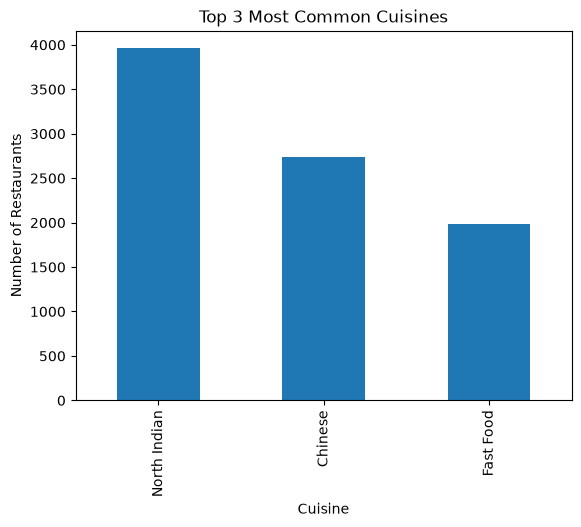

In [404]:
top_3.plot(kind="bar")

plt.title("Top 3 Most Common Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")

plt.show()

LEVEL 1 — TASK 2: CITY ANALYSIS

In [405]:
df["City"]
city_count = df["City"].value_counts()
print(city_count)

City
New Delhi    5473
Gurgaon      1118
Noida        1080
Faridabad     251
Ghaziabad      25
             ... 
Yorkton         1
Mohali          1
Panchkula       1
Bandung         1
Randburg        1
Name: count, Length: 141, dtype: int64


In [406]:
city_count.head(10)
city_count.head(10)
city_count.max()


np.int64(5473)

Average rating of each city

In [407]:
city_rating = df.groupby("City")["Aggregate rating"].mean()
print(city_rating)

City
Abu Dhabi          4.300000
Agra               3.965000
Ahmedabad          4.161905
Albany             3.555000
Allahabad          3.395000
                     ...   
Weirton            3.900000
Wellington City    4.250000
Winchester Bay     3.200000
Yorkton            3.300000
��stanbul          4.292857
Name: Aggregate rating, Length: 141, dtype: float64


Find highest-rated city

In [408]:
city_rating.sort_values(ascending=False)
city_rating.idxmax()


'Inner City'

LEVEL 1 — TASK 3: PRICE RANGE DISTRIBUTION

In [409]:
df["Price range"]
price_count = df["Price range"].value_counts().sort_index()

In [410]:
price_percentage = (price_count / len(df)) * 100


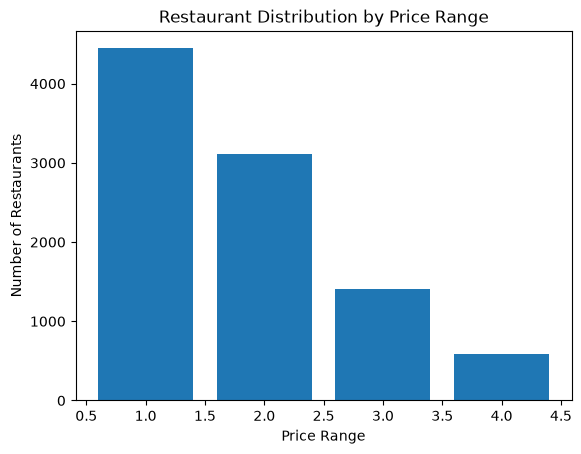

In [411]:
import matplotlib.pyplot as plt

plt.bar(price_count.index, price_count.values)

plt.title("Restaurant Distribution by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")

plt.show()

LEVEL 1 — TASK 4: ONLINE DELIVERY

In [412]:
df["Has Online delivery"]
delivery_count = df["Has Online delivery"].value_counts()
delivery_percentage = (delivery_count / len(df)) * 100
delivery_rating = df.groupby("Has Online delivery")["Aggregate rating"].mean()

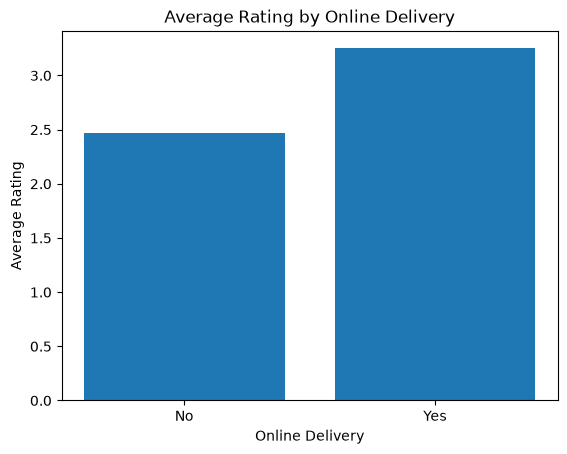

In [413]:
plt.bar(
    delivery_rating.index,
    delivery_rating.values
)

plt.title("Average Rating by Online Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Average Rating")

plt.show()

LEVEL 2 — TASK 1: CUISINE COMBINATION

In [414]:
df["Cuisines"].head(10)


0            French, Japanese, Desserts
1                              Japanese
2      Seafood, Asian, Filipino, Indian
3                       Japanese, Sushi
4                      Japanese, Korean
5                               Chinese
6                       Asian, European
7    Seafood, Filipino, Asian, European
8               European, Asian, Indian
9                              Filipino
Name: Cuisines, dtype: str

In [415]:
cuisine_combinations = df["Cuisines"].value_counts()
cuisine_combinations.head(10)

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

In [416]:
cuisine_combinations.head(1)

Cuisines
North Indian    936
Name: count, dtype: int64

In [417]:
combination_rating = df.groupby("Cuisines")["Aggregate rating"].mean()
combination_rating.sort_values(ascending=False).head(10)

Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Aggregate rating, dtype: float64

In [418]:
combination_analysis = df.groupby("Cuisines").agg(
    Restaurants=("Restaurant ID", "count"),
    Average_Rating=("Aggregate rating", "mean")
)
combination_analysis[
    combination_analysis["Restaurants"] >= 10
].sort_values(
    "Average_Rating",
    ascending=False
).head(10)

,Restaurants,Average_Rating
Cuisines,,
Modern Indian,11,4.345455
Indian,18,4.250000
Seafood,14,4.114286
Thai,16,4.100000
"Cafe, Continental, Italian",10,4.080000
"American, Burger",13,4.076923
"Japanese, Sushi",18,4.044444
"Pizza, Italian",19,3.668421
American,31,3.667742


LEVEL 2 — TASK 2: GEOGRAPHIC ANALYSIS

In [419]:
df[["Restaurant Name", "City", "Latitude", "Longitude"]].head()

,Restaurant Name,City,Latitude,Longitude
0,Le Petit Souffle,Makati City,14.565443,121.027535
1,Izakaya Kikufuji,Makati City,14.553708,121.014101
2,Heat - Edsa Shangri-La,Mandaluyong City,14.581404,121.056831
3,Ooma,Mandaluyong City,14.585318,121.056475
4,Sambo Kojin,Mandaluyong City,14.584450,121.057508


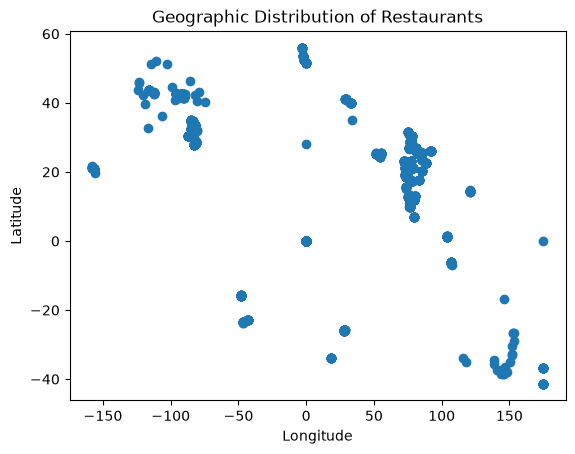

In [420]:
plt.scatter(
    df["Longitude"],
    df["Latitude"]
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Restaurants")

plt.show()

LEVEL 2 — TASK 3: RESTAURANT CHAINS

In [421]:
restaurant_counts = df["Restaurant Name"].value_counts()
restaurant_counts.head(20)

Restaurant Name
Cafe Coffee Day       83
Domino's Pizza        79
Subway                63
Green Chick Chop      51
McDonald's            48
Keventers             34
Pizza Hut             30
Giani                 29
Baskin Robbins        28
Barbeque Nation       26
Dunkin' Donuts        22
Giani's               22
Barista               22
Pind Balluchi         20
Costa Coffee          20
Sagar Ratna           19
Twenty Four Seven     19
Pizza Hut Delivery    19
Wah Ji Wah            19
KFC                   18
Name: count, dtype: int64

Find repeated restaurants

In [422]:
chains = restaurant_counts[
    restaurant_counts > 1
]
chains.head(20)

Restaurant Name
Cafe Coffee Day       83
Domino's Pizza        79
Subway                63
Green Chick Chop      51
McDonald's            48
Keventers             34
Pizza Hut             30
Giani                 29
Baskin Robbins        28
Barbeque Nation       26
Dunkin' Donuts        22
Giani's               22
Barista               22
Pind Balluchi         20
Costa Coffee          20
Sagar Ratna           19
Twenty Four Seven     19
Pizza Hut Delivery    19
Wah Ji Wah            19
KFC                   18
Name: count, dtype: int64

Analyze ratings

In [423]:
chain_rating = df.groupby(
    "Restaurant Name"
)["Aggregate rating"].mean()
chain_rating = df.groupby(
    "Restaurant Name"
)["Aggregate rating"].mean()

LEVEL 2 — TASK 4: RESTAURANT REVIEWS

In [424]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='str')

In [425]:
df["Rating text"].value_counts()

Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64

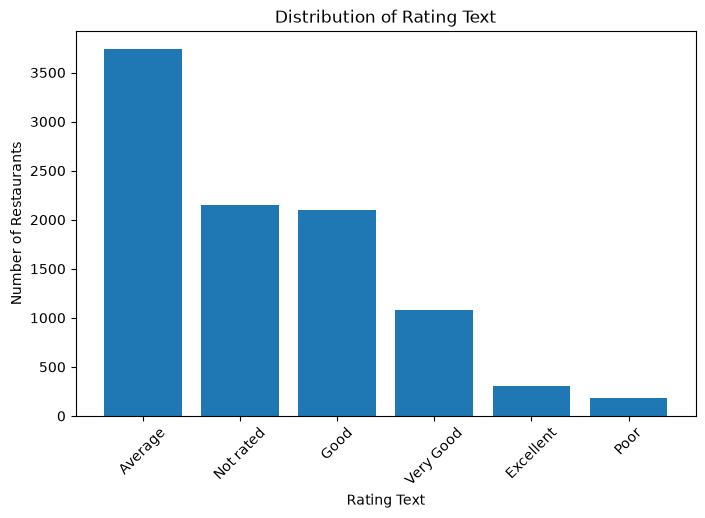

In [426]:
rating_text = df["Rating text"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    rating_text.index,
    rating_text.values
)

plt.title("Distribution of Rating Text")
plt.xlabel("Rating Text")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.show()

CONCLUSION:The supplied dataset does not contain free-text customer reviews. It contains the categorical Rating text field. Therefore, keyword frequency, average review length, and review-length versus rating analysis cannot be calculated from the provided dataset without an additional review-text dataset.

| Task                         | Main Pandas concepts                                      |
| ---------------------------- | --------------------------------------------------------- |
| Task 1 — Cuisine Combination | `value_counts()`, `groupby()`, `agg()`, `mean()`          |
| Task 2 — Geographic Analysis | `dropna()`, `scatter()`, `groupby()`                      |
| Task 3 — Restaurant Chains   | `value_counts()`, `groupby()`, `agg()`, `mean()`, `sum()` |
| Task 4 — Restaurant Reviews  | Data validation + identifying missing required fields     |
